# Ejemplo de Extracción de Características Radiómicas mediante PyRadiomics
PyRadiomics document: https://pyradiomics.readthedocs.io/en/latest/

## Instalación de PyRadiomics

In [1]:
!pip install git+https://github.com/AIM-Harvard/pyradiomics.git

  Cloning https://github.com/AIM-Harvard/pyradiomics.git to /tmp/pip-req-build-swnxjtsr
  Running command git clone --filter=blob:none --quiet https://github.com/AIM-Harvard/pyradiomics.git /tmp/pip-req-build-swnxjtsr
  Resolved https://github.com/AIM-Harvard/pyradiomics.git to commit 8ed579383b44806651c463d5e691f3b2b57522ab
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 8.9 MB/s eta 0:00:00
  Created wheel for pyradiomics: filename=pyradiomics-3.1.1.dev111+g8ed579383-cp313-cp313-linux_x86_64.whl size=121735 sha256=c09332c695800e582f398f9d42807f888d7beaa7cb5ac7dcae109fb4f092c32e
  Stored in directory: /tmp/pip-ephem-wheel-cache-lq_u65mw/wheels/b1/68/13/3b4579837527049ea5bffdedba2c3



---



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Importación de Librerías

In [3]:

import SimpleITK as sitk
import matplotlib.pyplot as plt
import numpy as np
from radiomics import featureextractor
import PIL



---



In [4]:
TC = "/content/drive/MyDrive/Radiomica/lung_001.nii.gz"

In [5]:
Label = "/content/drive/MyDrive/Radiomica/lung_001_label.nii.gz"

## Uso de un Caso de Segmentación de Nódulo Pulmonar del dataset Medical Segmentation Decathlon
http://medicaldecathlon.com/

Los archivos NifTI con las imágenes y segmentaciones se cargan a través de SimpleITK.

In [6]:
image = sitk.ReadImage(TC)
segmentation = sitk.ReadImage(Label)

---




In [7]:
type (image)

SimpleITK.SimpleITK.Image

In [8]:
texto = "esto es un texto"

In [9]:
type (texto)

str

In [10]:
sikt = ["budin", "auto, casa"]

In [11]:
sikt[1]

'auto, casa'

In [12]:
N= [0, sikt, 13,13,1414]

In [13]:
type(image)

SimpleITK.SimpleITK.Image

## Archivo de Configuración de TC de PyRadiomics
https://github.com/AIM-Harvard/pyradiomics/tree/master/examples/exampleSettings

In [14]:
TC_config = '/content/drive/MyDrive/Radiomica/CT_config.yaml'

In [15]:
type(TC_config)

str



---



## Visión de un Corte

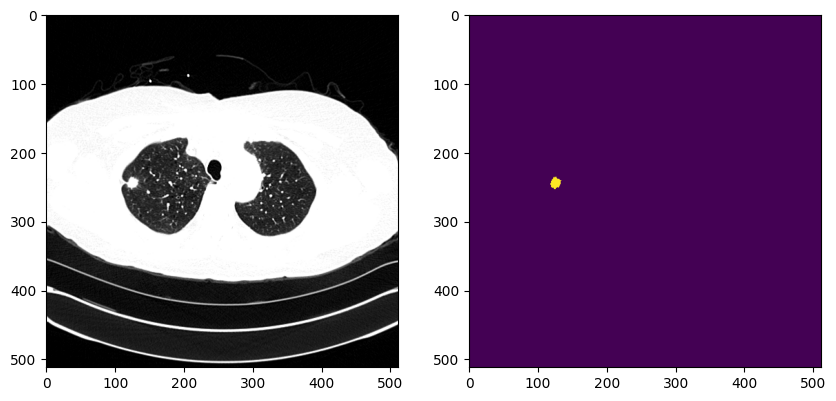

In [16]:
z = 240


hu_l = -1000
hu_h = -100

array_img = sitk.GetArrayFromImage(image)
array_seg = sitk.GetArrayFromImage(segmentation)

I = np.flipud(array_img[z, :, :])
S = np.flipud(array_seg[z, :, :])

plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.imshow(I, cmap='gray', vmin=hu_l, vmax=hu_h)
plt.subplot(1, 2, 2)
plt.imshow(S)
plt.show()

In [17]:
arrayImg = sitk.GetArrayFromImage(image)


In [18]:
arrayImg.min

<function ndarray.min>

In [19]:
type(arrayImg)

numpy.ndarray

In [20]:
corte237 = arrayImg[237,:,:]

array([[ 0,  0,  0, ..., 23, 18, 38],
       [ 0,  0,  0, ..., 17, 28, 35],
       [ 0,  0,  0, ..., 31, 27, 27],
       ...,
       [ 0,  0,  0, ..., 33, 36, 35],
       [ 0,  0,  0, ..., 19, 26, 27],
       [ 0,  0,  0, ...,  5,  6, 17]], dtype=uint8)
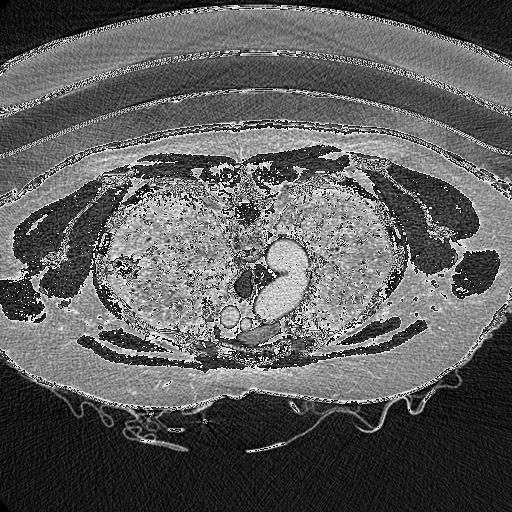

In [21]:
corte237.astype(np.uint8)

In [22]:
2**8

256

In [23]:
print(corte237.astype(np.uint8).mean())

93.73051452636719


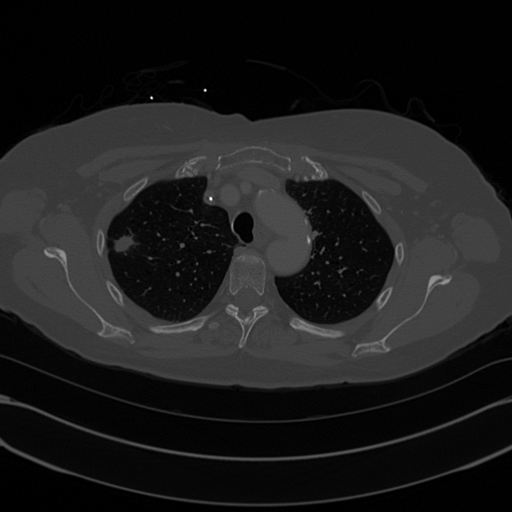

In [24]:
import numpy as np
import PIL.Image
from IPython.display import display

# Get min and max values for scaling
min_val = corte237.min()
max_val = corte237.max()

# Normalize to 0-255 range
scaled_corte237 = 255 * (corte237 - min_val) / (max_val - min_val)

# Convert to uint8
grayscale_image_uint8 = scaled_corte237.astype(np.uint8)

# Create a PIL Image from the uint8 array
imagenVisible_scaled = PIL.Image.fromarray(grayscale_image_uint8)

# Flip the image vertically
imagenVisible_scaled = imagenVisible_scaled.transpose(PIL.Image.FLIP_TOP_BOTTOM)

# Display the image
display(imagenVisible_scaled)

In [25]:
corte237

array([[-1024., -1024., -1024., ..., -1001., -1006.,  -986.],
       [-1024., -1024., -1024., ..., -1007.,  -996.,  -989.],
       [-1024., -1024., -1024., ...,  -993.,  -997.,  -997.],
       ...,
       [-1024., -1024., -1024., ...,  -991.,  -988.,  -989.],
       [-1024., -1024., -1024., ..., -1005.,  -998.,  -997.],
       [-1024., -1024., -1024., ..., -1019., -1018., -1007.]],
      dtype=float32)

In [26]:
corte237.max()

np.float32(3069.0)

In [27]:
grayscale_image_uint8.shape

(512, 512)

array([[0, 0, 0, ..., 1, 1, 2],
       [0, 0, 0, ..., 1, 1, 2],
       [0, 0, 0, ..., 1, 1, 1],
       ...,
       [0, 0, 0, ..., 2, 2, 2],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 0, 0, 1]], dtype=uint8)
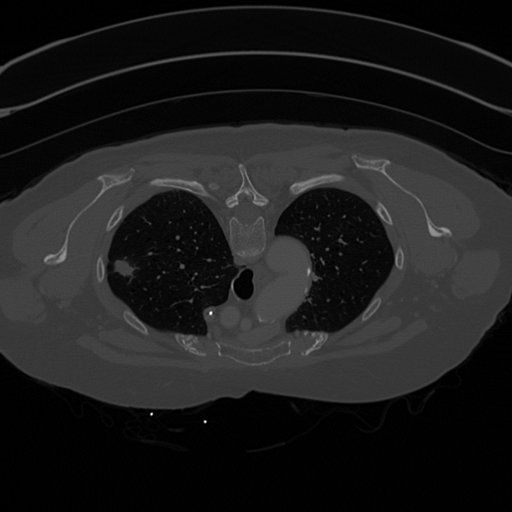

In [28]:
grayscale_image_uint8

In [29]:
corte_nodulo=grayscale_image_uint8.copy()

In [30]:
corte_nodulo=np.flipud(corte_nodulo)

array([[0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 2, 2, 2],
       ...,
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 2],
       [0, 0, 0, ..., 1, 1, 2]], dtype=uint8)
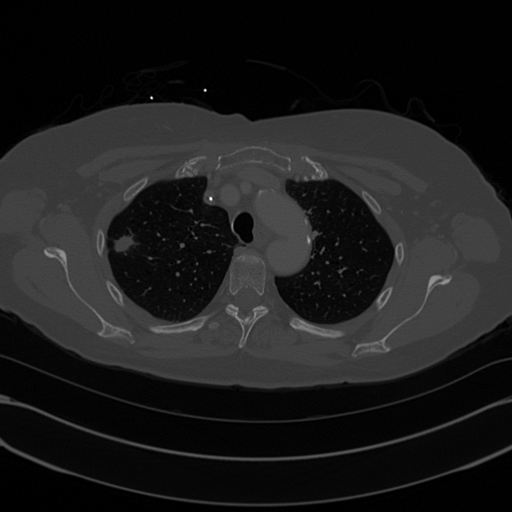

In [31]:
corte_nodulo

In [32]:
corte_nodulo.shape

(512, 512)

In [33]:
nodulo=corte_nodulo[220:270,100:150]

array([[64, 62, 64, ...,  7,  7,  8],
       [68, 64, 65, ..., 14,  6,  6],
       [65, 64, 65, ..., 19,  8,  7],
       ...,
       [61, 62, 66, ..., 10, 10, 10],
       [62, 60, 64, ..., 11, 11, 10],
       [64, 59, 59, ..., 11, 10, 11]], dtype=uint8)
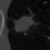

In [34]:
nodulo

In [35]:
nodulo_umbral=nodulo.copy()

In [36]:
nodulo_umbral[nodulo_umbral<60]=0

array([[64, 62, 64, ...,  0,  0,  0],
       [68, 64, 65, ...,  0,  0,  0],
       [65, 64, 65, ...,  0,  0,  0],
       ...,
       [61, 62, 66, ...,  0,  0,  0],
       [62, 60, 64, ...,  0,  0,  0],
       [64,  0,  0, ...,  0,  0,  0]], dtype=uint8)
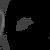

In [37]:
nodulo_umbral

In [38]:
nodulo_umbral[nodulo_umbral>70]=0

array([[64, 62, 64, ...,  0,  0,  0],
       [68, 64, 65, ...,  0,  0,  0],
       [65, 64, 65, ...,  0,  0,  0],
       ...,
       [61, 62, 66, ...,  0,  0,  0],
       [62, 60, 64, ...,  0,  0,  0],
       [64,  0,  0, ...,  0,  0,  0]], dtype=uint8)
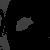

In [39]:
nodulo_umbral

In [40]:
#trabajar umbral con UH, de corte237

In [41]:
nodulo_umbralUH= corte237.copy()

In [42]:
nodulo_umbralUH[nodulo_umbralUH>40]=0

In [43]:
nodulo_umbralUH

array([[-1024., -1024., -1024., ..., -1001., -1006.,  -986.],
       [-1024., -1024., -1024., ..., -1007.,  -996.,  -989.],
       [-1024., -1024., -1024., ...,  -993.,  -997.,  -997.],
       ...,
       [-1024., -1024., -1024., ...,  -991.,  -988.,  -989.],
       [-1024., -1024., -1024., ..., -1005.,  -998.,  -997.],
       [-1024., -1024., -1024., ..., -1019., -1018., -1007.]],
      dtype=float32)

In [44]:
img_3c = np.zeros((512,512,3),dtype=np.uint8)

In [45]:
img_3c.shape

(512, 512, 3)

In [46]:
img_3c = np.zeros((512,512,3),dtype=np.uint8)
img_3c[:,:,0] = grayscale_image_uint8
img_3c[:,:,1] = grayscale_image_uint8
img_3c[:,:,2] = grayscale_image_uint8


array([[0, 0, 0, ..., 1, 1, 2],
       [0, 0, 0, ..., 1, 1, 2],
       [0, 0, 0, ..., 1, 1, 1],
       ...,
       [0, 0, 0, ..., 2, 2, 2],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 0, 0, 1]], dtype=uint8)
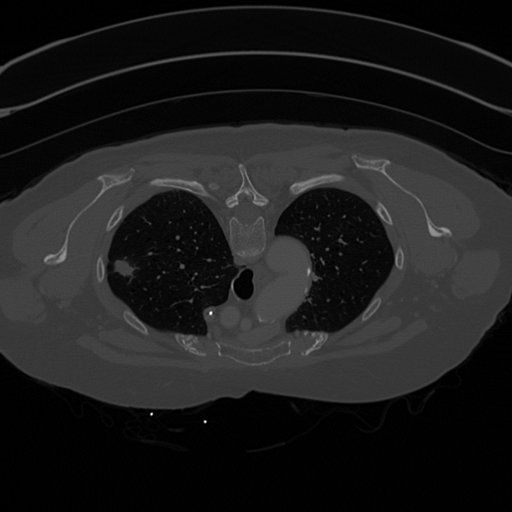

In [47]:
img_3c[:,:,1]

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [1, 1, 1]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [2, 2, 2],
        [2, 2, 2],
        [2, 2, 2]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [1, 1, 1],
        [1, 1, 1],
        [2, 2, 2]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [1, 1, 1],
        [1, 1, 1],
        [2, 2, 2]]], dtype=uint8)
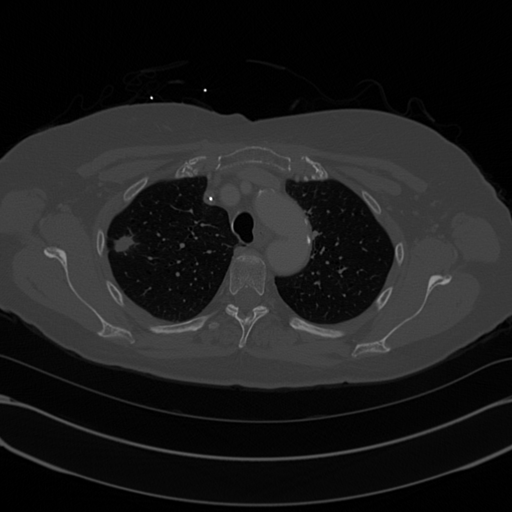

In [48]:
np.flipud(img_3c)

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [1, 1, 1],
        [1, 1, 1],
        [2, 2, 2]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [1, 1, 1],
        [1, 1, 1],
        [2, 2, 2]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [2, 2, 2],
        [2, 2, 2],
        [2, 2, 2]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [1, 1, 1]]], dtype=uint8)
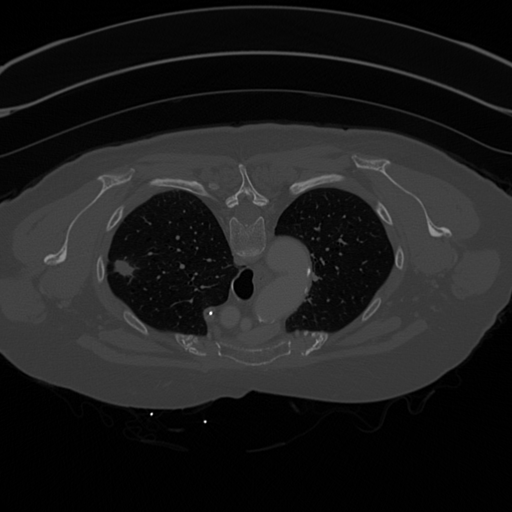

In [49]:
img_3c

segmentar con un cuadrado o box el nódulo y extraer solo los pixeles del nodulo a partir del umbral.-

In [50]:
img_3c[200:300,200:300,1] = grayscale_image_uint8[200:300,200:300]

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [1, 1, 1],
        [1, 1, 1],
        [2, 2, 2]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [1, 1, 1],
        [1, 1, 1],
        [2, 2, 2]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [2, 2, 2],
        [2, 2, 2],
        [2, 2, 2]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [1, 1, 1]]], dtype=uint8)
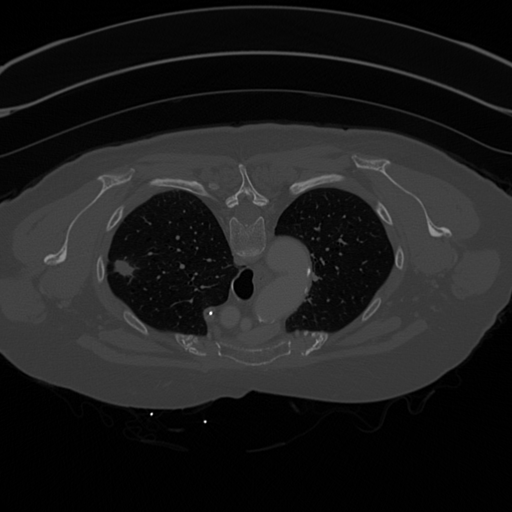

In [51]:
img_3c

In [52]:
img_3c[200:300,200:300,2] = grayscale_image_uint8[200:300,200:300]

In [53]:
img_3c[200:300,200:300,1] = 0
img_3c[200:300,200:300,0] = 0

In [54]:
img_3c = np.zeros((512,512,3),dtype=np.uint8)
img_3c[:,:,0] = grayscale_image_uint8
img_3c[:,:,1] = grayscale_image_uint8
img_3c[:,:,2] = grayscale_image_uint8

In [55]:
array_seg = sitk.GetArrayFromImage(segmentation)

In [56]:
array_seg.shape

(304, 512, 512)

In [57]:
corte_nodulo = array_seg[237,:,:]

In [58]:
corte_nodulo = corte_nodulo*255

In [59]:
img_3c[:,:,2] = corte_nodulo

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [1, 1, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [1, 1, 0],
        [1, 1, 0],
        [1, 1, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [2, 2, 0],
        [2, 2, 0],
        [2, 2, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [1, 1, 0],
        [1, 1, 0],
        [1, 1, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [1, 1, 0],
        [1, 1, 0],
        [2, 2, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [1, 1, 0],
        [1, 1, 0],
        [2, 2, 0]]], dtype=uint8)
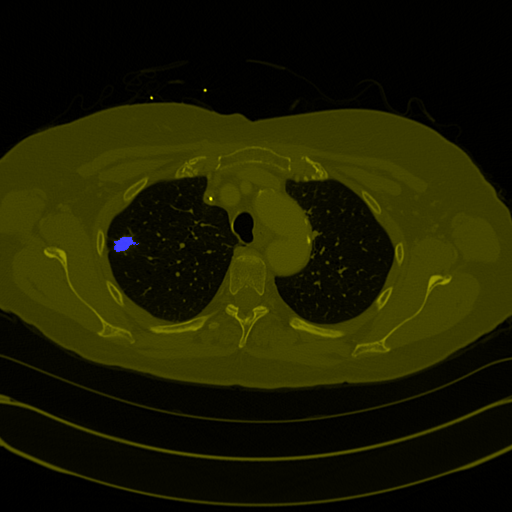

In [60]:
np.flipud(img_3c)

In [61]:
como hacer para que el resto de la TC de vea en escala de grises y no amarillo

SyntaxError: invalid syntax (411451320.py, line 1)

In [ ]:
corte237.mean()

In [ ]:
512*512

In [ ]:
imagenVisible = PIL.Image.fromarray(arrayImg[237,:,:])

In [ ]:
display(imagenVisible)

## Extracción de Características Radiómicas
Utilizamos el archivo de configuración para el setup del extractor.

Se provee la imagen y la etiqueta (ROI) mediante formato SimpleITK.

Etiquetas --> 0 Fondo.
              1 Nódulo.

In [ ]:
extractor = featureextractor.RadiomicsFeatureExtractor(TC_config, preCrop=True)

## Configuración del Extractor de Características Radiómicas
Documentación: https://pyradiomics.readthedocs.io/en/latest/customization.html#radiomics-customization-label

In [ ]:
extractor.settings

Se puede modificar la configuración, por ejemplo en el 'binWith'

extractor.settings['binWidth'] = 25



---



In [ ]:
caracteristicas_nodulo = extractor.execute(image, segmentation, label=1)

In [ ]:
caracteristicas_nodulo



---



### Cantidad de Características del Nódulo

In [ ]:
len(caracteristicas_nodulo)



---



### Lectura de Características del Nódulo

In [ ]:
caracteristica = 'original_shape_MeshVolume'
#caracteristica = 'original_firstorder_Minimum'

print(caracteristicas_nodulo[caracteristica])



---

